In this implementation the element moves only to a nearby coord
===

Plus right now it is possible that a element moves in one cycle more than once, because he moves to a coord, that have not been processed yet.
---

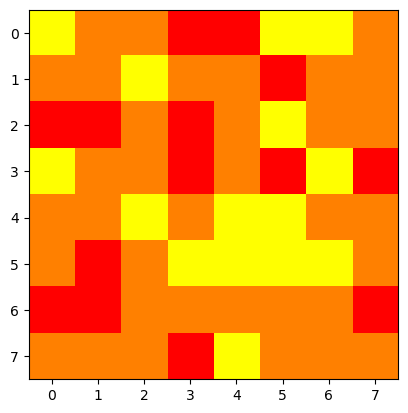

Update:  
 wantedToMove LAST run: 2


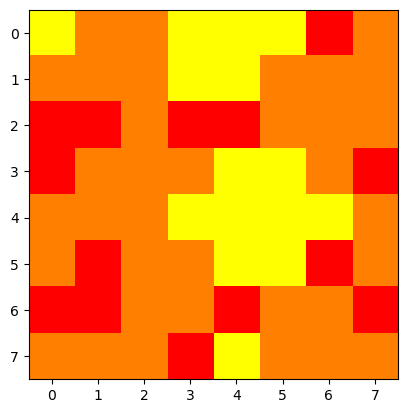

In [2]:
import numpy as np
import matplotlib.pyplot as plt


##OPTIONS
#set number of elements of each group
groupsOf=[35,15]

#set preference
pref=0.5

#set how far a element can see
#wARNING do NOT set to MORE then HALF of the lower dimension of the board. E.g. xDim=7, yDim=4, max visibility=2
visibility = 1

#set dimensions of the 2D board
xDim=8
yDim=8

#set maximal number of cycles
maxCycles=100


##constants
rng = np.random.default_rng(15648965215)  # seed

board = np.zeros((xDim,yDim), dtype = int)

neighbourIdx = np.array(np.arange(-visibility, visibility+1))

groups = np.array(groupsOf)
    
wantedToMove = 0


##helpers
#initGroups
def initGroups():
    for idx, group in enumerate(groups):
        for el in np.arange(group):
            suitableCoordinates = None
            while suitableCoordinates == None:
                y = rng.integers(yDim)
                x = rng.integers(xDim)
                if board[y,x] == 0:
                    suitableCoordinates = y,x

            board[suitableCoordinates] = idx + 1
                           
#ShowHeatMap
def heatMap():
    plt.imshow( board , cmap = 'autumn')
    plt.show()
#getNewCoordinates
def getNewCoordinate(x,y):
                yMove = rng.integers(-1,2)
                xMove = rng.integers(-1,2)
                yNew = y + yMove
                xNew = x + xMove
                if yNew >= yDim:
                    yNew -=yDim
                if xNew >= xDim:
                    xNew -=xDim
                newCoordinates = yNew, xNew
                return newCoordinates

#find empty coordinates around the current element
def getSuitableCoordinates(x,y):
    suitableCoordinates = None
    while suitableCoordinates == None:
        newCoordinates = getNewCoordinate(x,y)
        if board[newCoordinates] == 0:
            suitableCoordinates = newCoordinates
    return suitableCoordinates


##main logic
#iterate through 2D array using created coordinates
def oneCycle():
    for y in np.arange(yDim):
        for x in np.arange(xDim):
            currentEl = board[y,x]
            #is element NOT empty?
            if currentEl != 0:
                countSame = 0
                countOther = 0
                #look at neighbouring elements
                for row in neighbourIdx:
                    for col in neighbourIdx:
                        if row != 0 or col != 0:
                            yLookAt = y + row
                            xLookAt = x + col
                            if yLookAt >= yDim:
                                yLookAt -=yDim
                            if xLookAt >= xDim:
                                xLookAt -=xDim
                            neighbourEl = yLookAt,xLookAt
                            if board[neighbourEl] != 0:
                                if board[neighbourEl] == currentEl:
                                    countSame+=1
                                else:
                                    countOther+=1
                #move if an element is unhappy
                if countOther !=0:
                    if countSame + countOther != 8:
                        if countSame/(countSame + countOther) < pref or countSame==0:
                            global wantedToMove
                            wantedToMove+=1
                            suitableCoordinates = getSuitableCoordinates(x,y)
                            board[suitableCoordinates] = currentEl
                            board[y,x] = 0

initGroups()                            
heatMap()                            
for c in np.arange(maxCycles):
    global wantedToMove
    wantedToMove = 0
    oneCycle()
print('Update: ','\n','wantedToMove LAST run:',wantedToMove) 
heatMap()
            
    